In [2]:
import pandas as pd
df = pd.read_csv("batches_raw.csv")

In [3]:
df

,batch_id,product_name,production_line,start_date,end_date,reactor_temperature_C,reactor_pH,dissolved_oxygen_pct,agitation_rpm,feed_rate_L_h,biomass_concentration_g_L,product_concentration_g_L,yield_pct,qc_purity_pct,qc_potency_pct,qc_contaminants_flag,overall_qc_result,shift
0,B001,mAb_X,Line_A,2026-01-05,2026-01-07,36.5,7.10,40.0,250,3.5,12.0,3.1,88.5,99.2,101.5,pass,pass,Day
1,B002,mAb_X,Line_A,2026-01-10,2026-01-12,36.8,7.00,38.5,245,3.4,11.5,2.9,84.0,98.7,100.8,pass,pass,Night
2,B003,mAb_X,Line_A,2026-01-15,2026-01-17,37.2,7.25,42.0,255,3.6,12.3,3.2,90.1,99.5,102.0,pass,pass,Day
3,B004,mAb_X,Line_B,2026-01-20,2026-01-22,35.9,6.95,36.0,230,3.1,10.8,2.7,82.3,97.8,99.9,pass,pass,Night
4,B005,mAb_Y,Line_B,2026-01-25,2026-01-27,36.0,7.05,39.5,240,3.3,11.2,2.8,85.7,98.5,100.2,pass,pass,Day
5,B006,mAb_Y,Line_B,2026-02-01,2026-02-03,37.8,7.40,45.0,260,3.8,12.8,3.4,91.3,99.8,102.5,pass,pass,Night
6,B007,mAb_Y,Line_C,2026-02-06,2026-02-08,38.5,7.55,47.0,270,4.0,13.0,3.3,87.0,98.9,101.0,pass,pass,Day
7,B008,mAb_Y,Line_C,2026-02-11,2026-02-13,39.2,7.60,50.5,275,4.2,13.5,3.2,82.0,97.5,100.4,pass,fail,Night
8,B009,mAb_Z,Line_C,2026-02-16,2026-02-18,36.3,7.15,41.0,245,3.4,11.9,3.0,86.9,98.6,100.9,pass,pass,Day
9,B010,mAb_Z,Line_A,2026-02-21,2026-02-23,35.5,6.85,35.5,225,3.0,10.2,2.5,79.8,96.9,99.0,pass,fail,Night


In [6]:

print("First 5 rows:")
print(df.head())


First 5 rows:
  batch_id product_name production_line  start_date    end_date  \
0     B001        mAb_X          Line_A  2026-01-05  2026-01-07   
1     B002        mAb_X          Line_A  2026-01-10  2026-01-12   
2     B003        mAb_X          Line_A  2026-01-15  2026-01-17   
3     B004        mAb_X          Line_B  2026-01-20  2026-01-22   
4     B005        mAb_Y          Line_B  2026-01-25  2026-01-27   

   reactor_temperature_C  reactor_pH  dissolved_oxygen_pct  agitation_rpm  \
0                   36.5        7.10                  40.0            250   
1                   36.8        7.00                  38.5            245   
2                   37.2        7.25                  42.0            255   
3                   35.9        6.95                  36.0            230   
4                   36.0        7.05                  39.5            240   

   feed_rate_L_h  biomass_concentration_g_L  product_concentration_g_L  \
0            3.5                       12.0   

In [8]:
print("Columns:")
print(df.columns)

print(" ")
print("Basic statistics for numeric columns:")
print(df.describe())

Columns:
Index(['batch_id', 'product_name', 'production_line', 'start_date', 'end_date',
       'reactor_temperature_C', 'reactor_pH', 'dissolved_oxygen_pct',
       'agitation_rpm', 'feed_rate_L_h', 'biomass_concentration_g_L',
       'product_concentration_g_L', 'yield_pct', 'qc_purity_pct',
       'qc_potency_pct', 'qc_contaminants_flag', 'overall_qc_result', 'shift'],
      dtype='str')
 
Basic statistics for numeric columns:
       reactor_temperature_C  reactor_pH  dissolved_oxygen_pct  agitation_rpm  \
count              15.000000   15.000000             15.000000      15.000000   
mean               37.246667    7.256667             42.700000     253.666667   
std                 1.267093    0.271811              4.883646      16.633300   
min                35.500000    6.850000             35.500000     225.000000   
25%                36.250000    7.050000             39.250000     242.500000   
50%                37.000000    7.200000             42.000000     255.000000   

In [11]:

avg_yield = df["yield_pct"].mean()
min_yield = df["yield_pct"].min()
max_yield = df["yield_pct"].max()

print(f"Average yield (%): {avg_yield:.2f}")
print(f"Minimum yield (%): {min_yield:.2f}")
print(f"Maximum yield (%): {max_yield:.2f}")

Average yield (%): 86.11
Minimum yield (%): 79.80
Maximum yield (%): 92.20


In [13]:

low_yield_threshold = 85.0

low_yield_batches = df[df["yield_pct"] < low_yield_threshold]

print(f"Number of low-yield batches (yield < {low_yield_threshold}%): {len(low_yield_batches)}")
print("Low-yield batch IDs:")
print(low_yield_batches[["batch_id", "yield_pct"]])

Number of low-yield batches (yield < 85.0%): 6
Low-yield batch IDs:
   batch_id  yield_pct
1      B002       84.0
3      B004       82.3
7      B008       82.0
9      B010       79.8
13     B014       81.5
14     B015       84.9


In [14]:

qc_counts = df["overall_qc_result"].value_counts()

print("Quality check results (overall_qc_result):")
print(qc_counts)

Quality check results (overall_qc_result):
overall_qc_result
pass    12
fail     3
Name: count, dtype: int64


In [17]:
temp_min, temp_max = 36.0, 38.5        # °C
ph_min, ph_max       = 6.9, 7.5        # pH
do_min, do_max       = 35.0, 48.0      # % dissolved oxygen

df["temp_out_of_range"] = df["reactor_temperature_C"].between(temp_min, temp_max)
df["ph_out_of_range"]   = df["reactor_pH"].between(ph_min, ph_max)
df["do_out_of_range"]   = df["dissolved_oxygen_pct"].between(do_min, do_max)

print("Batches with temperature out of normal range:")
print(df[df["temp_out_of_range"]][["batch_id", "reactor_temperature_C"]])
print("")
print("Batches with pH out of normal range:")
print(df[df["ph_out_of_range"]][["batch_id", "reactor_pH"]])
print("")
print("Batches with dissolved oxygen out of normal range:")
print(df[df["do_out_of_range"]][["batch_id", "dissolved_oxygen_pct"]])

Batches with temperature out of normal range:
   batch_id  reactor_temperature_C
0      B001                   36.5
1      B002                   36.8
2      B003                   37.2
4      B005                   36.0
5      B006                   37.8
6      B007                   38.5
8      B009                   36.3
10     B011                   37.0
11     B012                   37.5
14     B015                   36.2

Batches with pH out of normal range:
   batch_id  reactor_pH
0      B001        7.10
1      B002        7.00
2      B003        7.25
3      B004        6.95
4      B005        7.05
5      B006        7.40
8      B009        7.15
10     B011        7.20
11     B012        7.35
14     B015        7.05

Batches with dissolved oxygen out of normal range:
   batch_id  dissolved_oxygen_pct
0      B001                  40.0
1      B002                  38.5
2      B003                  42.0
3      B004                  36.0
4      B005                  39.5
5      B006

In [21]:
yield_by_product = df.groupby("product_name")["yield_pct"].agg(["mean", "min", "max", "count"])
print("Yield statistics by product_name:")
print(yield_by_product)
print("")
yield_by_line = df.groupby("production_line")["yield_pct"].agg(["mean", "min", "max", "count"])
print("Yield statistics by production_line:")
print(yield_by_line)

Yield statistics by product_name:
               mean   min   max  count
product_name                          
mAb_X         87.42  82.3  92.2      5
mAb_Y         85.50  81.5  91.3      5
mAb_Z         85.40  79.8  89.4      5

Yield statistics by production_line:
                      mean   min   max  count
production_line                              
Line_A           86.116667  79.8  90.1      6
Line_B           87.500000  82.3  92.2      5
Line_C           84.350000  81.5  87.0      4


In [27]:
total_batches = len(df)
qc_pass_batches = (df["overall_qc_result"] == "pass").sum()

qc_pass_rate = qc_pass_batches / total_batches * 100

print(f"Total batches: {total_batches}")
print("")
print(f"Batches with QC pass: {qc_pass_batches}")
print("")
print(f"QC pass rate (%): {qc_pass_rate:.1f}")

Total batches: 15

Batches with QC pass: 12

QC pass rate (%): 80.0


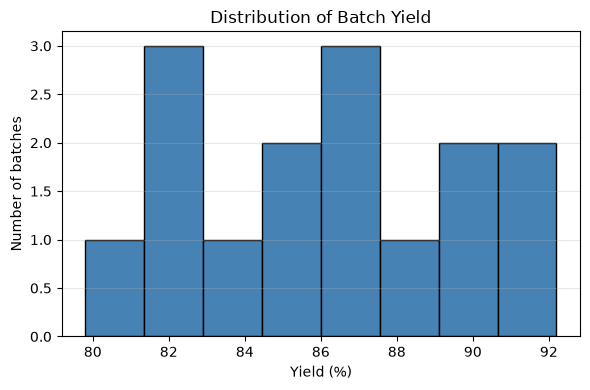

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
df["yield_pct"].plot(kind="hist", bins=8, color="steelblue", edgecolor="black")
plt.xlabel("Yield (%)")
plt.ylabel("Number of batches")
plt.title("Distribution of Batch Yield")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

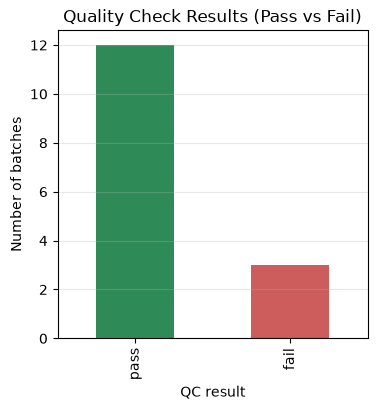

In [35]:
qc_counts = df["overall_qc_result"].value_counts()

plt.figure(figsize=(4,4))
qc_counts.plot(kind="bar", color=["seagreen", "indianred"])
plt.xlabel("QC result")
plt.ylabel("Number of batches")
plt.grid(axis="y", alpha=0.3)
plt.title("Quality Check Results (Pass vs Fail)")
plt.show()

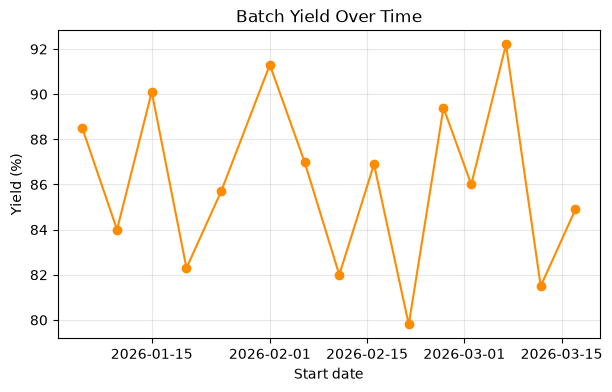

In [37]:
df["start_date"] = pd.to_datetime(df["start_date"])

df_sorted = df.sort_values("start_date")

plt.figure(figsize=(7,4))
plt.plot(df_sorted["start_date"], df_sorted["yield_pct"], marker="o", color="darkorange")
plt.xlabel("Start date")
plt.ylabel("Yield (%)")
plt.title("Batch Yield Over Time")
plt.grid(True, alpha=0.3)
plt.show()

In [41]:
cols_for_powerbi = [
    "batch_id",
    "product_name",
    "production_line",
    "start_date",
    "yield_pct",
    "reactor_temperature_C",
    "reactor_pH",
    "dissolved_oxygen_pct",
    "overall_qc_result",
]

df_clean = df[cols_for_powerbi].copy()

df_clean.to_csv("batches_clean_for_powerbi.csv", index=False)

print("Exported cleaned dataset to data/batches_clean_for_powerbi.csv")

Exported cleaned dataset to data/batches_clean_for_powerbi.csv
